## Benefit #1: Short Term Momemory
- This is first benefit.
- See more in memory folder in this repo.

## Benefit #2: Fault Tolerance

In [1]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time

In [2]:
# 1. Define the state
class CrashState(TypedDict):
  input: str
  step1: str
  step2: str
  step3: str

- In below steps, at step 2 we will simulate crash.
- First we are keeping long-running hang, and we will do key-board interrupt to simulate the crash.
- Then we will start running from crashed state only i.e. from step 2, not from step 1, which is called `Fault Tolerance`.

In [4]:
# 2. Define Steps
def step_1(state: CrashState) -> CrashState:
  print("Step1 executed")
  return {"step1": "done", "input": state['input']}

def step_2(state: CrashState) -> CrashState:
  print("Step2 hanging......Now manually interrupt from the notebook toolbar (STOP BUTTON)")
  time.sleep(30) 
  return {'step2': 'done'}

def step_3(state: CrashState) -> CrashState:
  print("Step3 executed")
  return {'step3': 'done'}

In [5]:
# 3. build the graph
builder = StateGraph(CrashState)

builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

builder.add_edge(START, "step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer = checkpointer)

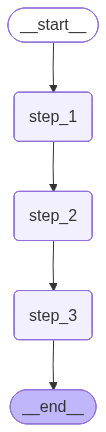

In [6]:
graph

In [7]:
try:
  print("Running graph, please manually interrupt during step2...")
  graph.invoke({"input": "start1"}, config={"configurable": {"thread_id": 'thread-1'}})
except KeyboardInterrupt:
  print("Kernel manually interrupted (crash simulated)")

Running graph, please manually interrupt during step2...
Step1 executed
Step2 hanging......Now manually interrupt from the notebook toolbar (STOP BUTTON)
Kernel manually interrupted (crash simulated)


In [8]:
graph.get_state({"configurable": {"thread_id": 'thread-1'}})

StateSnapshot(values={'input': 'start1', 'step1': 'done'}, next=('step_2',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f17d51c-de56-67f4-8001-3ea305ced338'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-07-11T17:56:12.538241+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f17d51c-de52-6ed6-8000-41e34095cacc'}}, tasks=(PregelTask(id='785cbfbd-baeb-0ed8-87fb-47b11e83218f', name='step_2', path=('__pregel_pull', 'step_2'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [9]:
list(graph.get_state_history({"configurable": {"thread_id": 'thread-1'}}))

[StateSnapshot(values={'input': 'start1', 'step1': 'done'}, next=('step_2',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f17d51c-de56-67f4-8001-3ea305ced338'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-07-11T17:56:12.538241+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f17d51c-de52-6ed6-8000-41e34095cacc'}}, tasks=(PregelTask(id='785cbfbd-baeb-0ed8-87fb-47b11e83218f', name='step_2', path=('__pregel_pull', 'step_2'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'input': 'start1'}, next=('step_1',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f17d51c-de52-6ed6-8000-41e34095cacc'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-07-11T17:56:12.536788+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', '

- Now rerun to show resume from crashed step (styep 2) i.e. managing fault-tolerance.
- Also here we used hardcoded static thread id `thread_1`, so we will just use the same id only.

In [10]:
final_state = graph.invoke(None, config={"configurable": {"thread_id": 'thread-1'}})
print("\nFinal State: ", final_state)

Step2 hanging......Now manually interrupt from the notebook toolbar (STOP BUTTON)
Step3 executed

Final State:  {'input': 'start1', 'step1': 'done', 'step2': 'done', 'step3': 'done'}


In [11]:
graph.get_state({"configurable": {"thread_id": 'thread-1'}})

StateSnapshot(values={'input': 'start1', 'step1': 'done', 'step2': 'done', 'step3': 'done'}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f17d524-a2fa-6d54-8003-6860a6225aac'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-07-11T17:59:41.062472+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f17d524-a2f8-6828-8002-5509715427c7'}}, tasks=(), interrupts=())

In [12]:
list(graph.get_state_history({"configurable": {"thread_id": 'thread-1'}}))

[StateSnapshot(values={'input': 'start1', 'step1': 'done', 'step2': 'done', 'step3': 'done'}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f17d524-a2fa-6d54-8003-6860a6225aac'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-07-11T17:59:41.062472+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f17d524-a2f8-6828-8002-5509715427c7'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'input': 'start1', 'step1': 'done', 'step2': 'done'}, next=('step_3',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f17d524-a2f8-6828-8002-5509715427c7'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-07-11T17:59:41.061507+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f17d51c-de56-67f4-8001-3ea305ced338'}}, tasks=(PregelTask(id='c98cc277-6472-1c

## Benefit #3: Human in the Loop (HITL)
- It is next benefit before.
- There is a dedicated video and notebook later.

## Benefit #4: Time Travel
- Starting from the `graph` defined above.
- Using runs happened already.
- In time travel we can revisit details of any particular checkpoint, by providing the corresponding checkpoint id.
- In below code, each time we will run this code, this checkpoint id should be changed according to latest run.

In [13]:
graph.get_state({"configurable": {"thread_id": 'thread-1', 'checkpoint_id': '1f17d524-a2f8-6828-8002-5509715427c7'}})

StateSnapshot(values={'input': 'start1', 'step1': 'done', 'step2': 'done'}, next=('step_3',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_id': '1f17d524-a2f8-6828-8002-5509715427c7'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-07-11T17:59:41.061507+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f17d51c-de56-67f4-8001-3ea305ced338'}}, tasks=(PregelTask(id='c98cc277-6472-1ccf-51bd-43077691a19b', name='step_3', path=('__pregel_pull', 'step_3'), error=None, interrupts=(), state=None, result={'step3': 'done'}),), interrupts=())

- Via below code, we can execute steps from provided checkpoint id.

In [14]:
graph.invoke(None, config={"configurable": {"thread_id": 'thread-1', 'checkpoint_id': '1f17d524-a2f8-6828-8002-5509715427c7'}})

Step3 executed


{'input': 'start1', 'step1': 'done', 'step2': 'done', 'step3': 'done'}

In [15]:
list(graph.get_state_history({"configurable": {"thread_id": 'thread-1'}}))

[StateSnapshot(values={'input': 'start1', 'step1': 'done', 'step2': 'done', 'step3': 'done'}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f17d538-e506-64d9-8004-1f9b247c72bb'}}, metadata={'source': 'loop', 'step': 4, 'parents': {}}, created_at='2026-07-11T18:08:44.858683+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f17d538-e4fb-6f18-8003-3619411cbcc1'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'input': 'start1', 'step1': 'done', 'step2': 'done'}, next=('step_3',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f17d538-e4fb-6f18-8003-3619411cbcc1'}}, metadata={'source': 'fork', 'step': 3, 'parents': {}}, created_at='2026-07-11T18:08:44.854389+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f17d524-a2f8-6828-8002-5509715427c7'}}, tasks=(PregelTask(id='9307e528-fd04-e8

- Here see, we can see last two new snapshots of states got added.
- Till last run, all three steps were done.
- Now when we invoked from step 2, two new state snapshot got added - one for starting node and one for end node.

## Benefit #5: Update State
- Here we can update any previous step via invoking again.
- It will be stored as new state snapshot in memory.
- Using joke generation example from `concept` notebook.
- Also here to change checkpoint id at each run according to latest run. `cjeckpoint_id` of that step to provide from where we want to update.

In [30]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import AIMessage
from langgraph.checkpoint.memory import InMemorySaver 
import re

prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant. Answer clearly and directly."),
    ("human", "{input}")
])

llm = ChatOpenAI()

class JokeState(TypedDict):
  topic: str
  joke: str
  explanation: str

def generate_joke(state: JokeState):
  prompt = f"Generate a joke on the topic {state['topic']}"
  response = llm.invoke(prompt).content
  return {'joke': response}

def generate_explanation(state: JokeState):
  prompt = f"write an explanation for the joke - {state['joke']}"
  response = llm.invoke(prompt).content
  return {'explanation': response}

graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

In [31]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic': 'pizza'}, config = config1)

{'topic': 'pizza',
 'joke': 'Why did the pizza go to the doctor?\nBecause it was feeling saucy!',
 'explanation': 'This joke plays on the double meaning of the word "saucy." On one hand, "saucy" can mean bold, lively, or cheeky. So it suggests that the pizza was feeling confident or adventurous in seeking medical help. But on the other hand, "saucy" can also refer to a type of topping on a pizza, so the joke also plays on the idea that the pizza went to the doctor because it was literally feeling "saucy." The humor comes from the clever wordplay and the unexpected twist in the punchline.'}

In [32]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the doctor?\nBecause it was feeling saucy!', 'explanation': 'This joke plays on the double meaning of the word "saucy." On one hand, "saucy" can mean bold, lively, or cheeky. So it suggests that the pizza was feeling confident or adventurous in seeking medical help. But on the other hand, "saucy" can also refer to a type of topping on a pizza, so the joke also plays on the idea that the pizza went to the doctor because it was literally feeling "saucy." The humor comes from the clever wordplay and the unexpected twist in the punchline.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f17d589-486e-644e-8002-2096ada29f77'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-07-11T18:44:42.765804+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f17d589-3811-67be-8001-6e5272324dd2'}}, tasks=(), interrupt

In [33]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the doctor?\nBecause it was feeling saucy!', 'explanation': 'This joke plays on the double meaning of the word "saucy." On one hand, "saucy" can mean bold, lively, or cheeky. So it suggests that the pizza was feeling confident or adventurous in seeking medical help. But on the other hand, "saucy" can also refer to a type of topping on a pizza, so the joke also plays on the idea that the pizza went to the doctor because it was literally feeling "saucy." The humor comes from the clever wordplay and the unexpected twist in the punchline.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f17d589-486e-644e-8002-2096ada29f77'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-07-11T18:44:42.765804+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f17d589-3811-67be-8001-6e5272324dd2'}}, tasks=(), interrup

In [38]:
workflow.update_state({"configurable": {"thread_id": '1', 'checkpoint_id': '1f17d589-1503-6ca2-8000-e68144dee4b3', "checkpoint_ns": ""}}, {'topic': 'samosa'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f17d58b-2937-660f-8001-aae5bba47c44'}}

In [39]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f17d58b-2937-660f-8001-aae5bba47c44'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-07-11T18:45:33.179830+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f17d589-1503-6ca2-8000-e68144dee4b3'}}, tasks=(PregelTask(id='a162b8b1-1aea-3d13-801f-aaffffb48df0', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f17d589-48db-6f6c-8000-1afff184432c'}}, metadata={'source': 'update', 'step': 0, 'parents': {}}, created_at='2026-07-11T18:44:42.810747+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id

In [40]:
workflow.invoke(None, {"configurable": {"thread_id": '1', 'checkpoint_id': '1f17d58b-2937-660f-8001-aae5bba47c44'}})

{'topic': 'samosa',
 'joke': "Why did the samosa go to the party alone?\nBecause he couldn't find a date to curry favor with!",
 'explanation': 'This joke plays on the pun of "curry favor," which means to seek to gain an advantage by flattery or attention. In this case, the samosa went to the party alone because it couldn\'t find a date to curry favor with, meaning it couldn\'t find someone to flatter or impress at the party. The humor comes from the play on words and the unexpected twist in the punchline.'}

In [41]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa', 'joke': "Why did the samosa go to the party alone?\nBecause he couldn't find a date to curry favor with!", 'explanation': 'This joke plays on the pun of "curry favor," which means to seek to gain an advantage by flattery or attention. In this case, the samosa went to the party alone because it couldn\'t find a date to curry favor with, meaning it couldn\'t find someone to flatter or impress at the party. The humor comes from the play on words and the unexpected twist in the punchline.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f17d58d-7aae-6164-8003-ce18ce3c3d05'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-07-11T18:46:35.408985+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f17d58d-6b09-6a25-8002-01c48288e97e'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'samosa', 'joke': "Why did the samosa go to